# Cross-validation

In this lab, we will illustrate the phenomenon of under-fitting and over-fitting using a regression problem. We'll generate a dataset based on a quadratic function and observe how models of varying complexity perform.

In [1]:
import pandas as pd

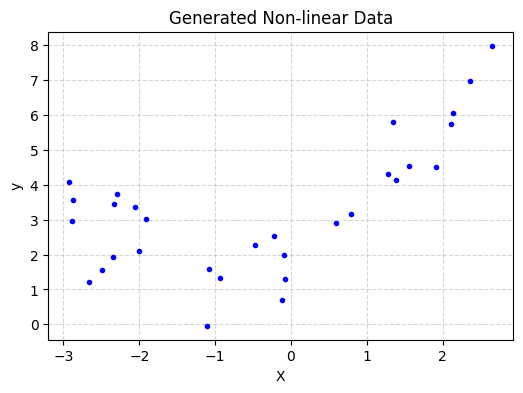

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(11)

# Generate 30 data points
m = 30
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

# Plot the generated data points
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Non-linear Data")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Let's fit this data using different models and compare between them:

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Degree 1": Pipeline([
        ('poly', PolynomialFeatures(degree=1)),
        ('regressor', LinearRegression())
    ]),
    "Degree 2": Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('regressor', LinearRegression())
    ]),
    "Degree 15": Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('regressor', LinearRegression())
    ])
}

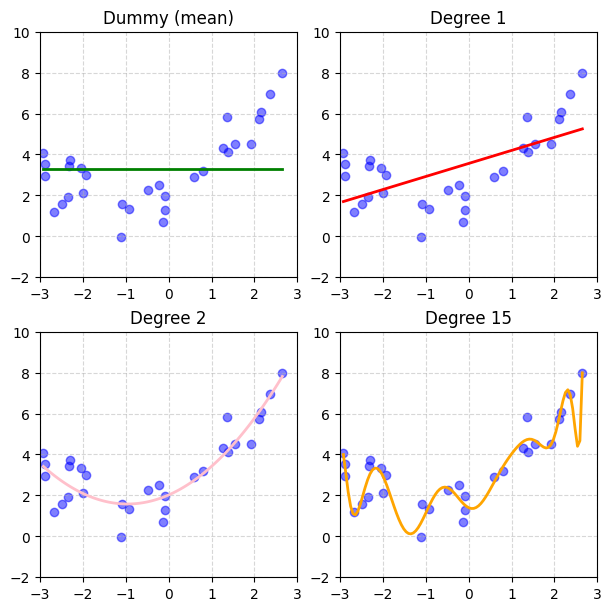

In [4]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(100, 1)

fig, axes = plt.subplots(2, 2, figsize=(6, 6), constrained_layout=True)
axes = axes.flatten()

colors = ['green', 'red', 'pink', 'orange']

for i, (name, model) in enumerate(models.items()):
    # Fit the model
    model.fit(X, y)
    
    # Generate predictions for plotting the regression curve
    y_plot = model.predict(X_plot)
    
    # Plot original data points and the regression curve
    axes[i].scatter(X, y, color='blue', alpha=0.5)
    axes[i].plot(X_plot, y_plot, color=colors[i], linewidth=2)
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-2, 10)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_title(name)

plt.show()

## Estimating Generalization Performance with Cross-Validation

**Cross-validation (CV)** is a performance estimation scheme in which the model is validated without using the held-out / test data. This is done by repeatedly splitting the training data itself into train-test splits. Since this test comes from within, we call it the validation set, and call this whole thing cross-validation.

![](../assets/cv_parallel.png)

Then, we use the `cross_validate` and pass it the `cv` parameter as the strategy:

In [5]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold

# Cross-validation Strategy
k_fold = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    models['Degree 1'], X, y,
    cv=k_fold,

    # Training the estimator and computing the score are parallelized
    # over the cross-validation splits.
    # None means 1.
    # -1 means using all processors.
    n_jobs=-1,
    
    # Note: we use the Negative of the MAE (`neg_mean_absolute_error`)
    # because a *Score* in scikit-learn means: higher is better,
    # whereas MAE is an error metric (lower is better).
    # So we invert the sign to indicate just that.
    scoring="neg_mean_absolute_error",

    return_train_score=True
)

Here is a diagram to illustrate parallel execution in `cross_validate` with `n_jobs`:

```{mermaid}
graph LR
  A[Training Data] -->|Split 1| B1[Worker 1]
  A -->|Split 2| B2[Worker 2]
  A -->|Split 3| B3[Worker 3]
  A -->|"..."| B4["..."]
  A -->|Split 10| B10[Worker 10]
  B1 -- Score --> C[Aggregate Scores]
  B2 -- Score --> C
  B3 -- Score --> C
  B4 -- Score --> C
  B10 -- Score --> C
```

Let's show the results of the cross-validation:

In [6]:
df = pd.DataFrame(cv_results)

# invert the sign to get MAE
df['test_score'] = -df['test_score']
df['train_score'] = -df['train_score']

df[['train_score', 'test_score']]

,train_score,test_score
0,1.247079,1.200327
1,1.133809,2.081100
2,1.190744,1.395644
3,1.206733,1.268993
4,1.244861,0.978988
5,1.221691,1.288539
6,1.270247,0.699780
7,1.162073,2.126412
8,1.266994,0.981411
9,1.194800,1.419145


Now let's do it for each of the three models, and average the results:

In [7]:
# We will store the results in a list and then display them as a DataFrame
cv_results = []

for name, model in models.items():
    # Perform 5-fold cross validation. 
    scores = cross_validate(
        model, X, y,
        cv=k_fold,
        n_jobs=-1,
        scoring='neg_mean_absolute_error', 
        return_train_score=True
    )
    
    # Calculate the mean of the folds and invert the sign to get MAE
    for s in -scores['train_score']:
        cv_results.append({
        'Model': name,
        'Score': s,
        'Type': 'train'
    })

    for s in -scores['test_score']:
        cv_results.append({
        'Model': name,
        'Score': s,
        'Type': 'test'
    })

In [8]:
results_df = pd.DataFrame(cv_results)
results_df

,Model,Score,Type
0,Dummy (mean),1.558206,train
1,Dummy (mean),1.320230,train
2,Dummy (mean),1.414550,train
3,Dummy (mean),1.584819,train
4,Dummy (mean),1.439854,train
...,...,...,...
75,Degree 15,0.666832,test
76,Degree 15,0.724553,test
77,Degree 15,1.115978,test
78,Degree 15,1.125640,test


Let's compare the three models:

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

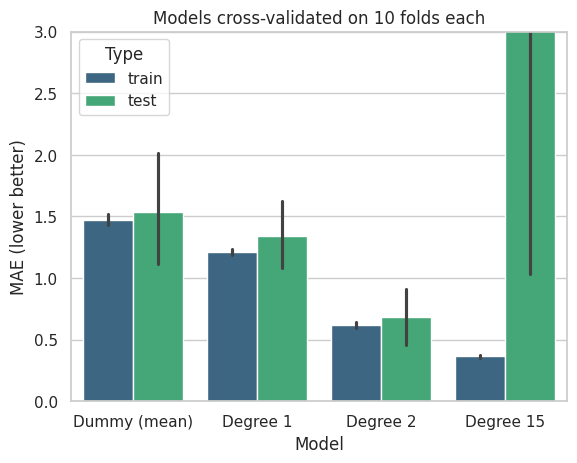

In [11]:
ax = sns.barplot(
    data=results_df, 
    x="Model",
    y="Score",
    hue="Type", 
    palette="viridis",
)

plt.title("Models cross-validated on 10 folds each")
plt.ylabel("MAE (lower better)")
plt.xlabel("Model")
plt.ylim(0, 3)
plt.show()


- **Under-fitting**: Both the Train MAE and Validation MAE are relatively high. The model is too simple (high bias) and cannot fit the data well.
- **Good Fit**: Both Train and Validation MAE are low. The model generalizes well to unseen folds, which agrees with our visual intuition.
- **Over-fitting**: The Train MAE is extremely low (sometimes near zero), but the Validation MAE is very high! The complex model memorized the training patterns (high variance) and fails completely on new, unseen data.

Thus, Cross-Validation provides an automated, numerical approach for verifying the **generalizability** of our model, steering us towards the **Good Fit**.

While we have shown the concept for a regression problem using 1 feature. It:

- applies to classification
- applies to more features